In [1]:
!pip install sentence-transformers matplotlib seaborn

from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
sentences = [
"The batsman scored a century in the match.",
"The bowler took five wickets in the game.",
"The team won the cricket match by 50 runs.",
"The captain set an aggressive field placement.",

"She prepared a delicious pasta for dinner.",
"Baking a cake requires precise measurements.",
"The chef cooked a spicy curry.",

"Cybersecurity protects systems from digital attacks.",
"Strong passwords help prevent hacking.",
"Encryption secures sensitive data online."
]

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print(embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(10, 384)


In [4]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.0000002   0.60159874  0.62639797  0.2394622  -0.03090702  0.1319129
   0.18973735 -0.00584988 -0.0058036  -0.00601878]
 [ 0.60159874  1.0000002   0.6125785   0.21855669  0.12542312  0.09753844
   0.25623846  0.01455323  0.00550525  0.04351751]
 [ 0.62639797  0.6125785   1.0000001   0.16741493  0.00863729  0.01645451
   0.08617315 -0.00585666  0.01028798 -0.03146171]
 [ 0.2394622   0.21855669  0.16741493  1.0000002  -0.01688397 -0.05845999
  -0.00165556 -0.00425957  0.07139543 -0.02128411]
 [-0.03090702  0.12542312  0.00863729 -0.01688397  0.99999976  0.13827962
   0.27936712 -0.04957552 -0.03569691  0.02890887]
 [ 0.1319129   0.09753844  0.01645451 -0.05845999  0.13827962  0.9999999
   0.15651625 -0.01049969 -0.03514573  0.08214407]
 [ 0.18973735  0.25623846  0.08617315 -0.00165556  0.27936712  0.15651625
   0.9999997  -0.01964654  0.02123731 -0.01974509]
 [-0.00584988  0.01455323 -0.00585666 -0.00425957 -0.04957552 -0.01049969
  -0.01964654  1.0000002   0.42286527  0.49058336]
 [

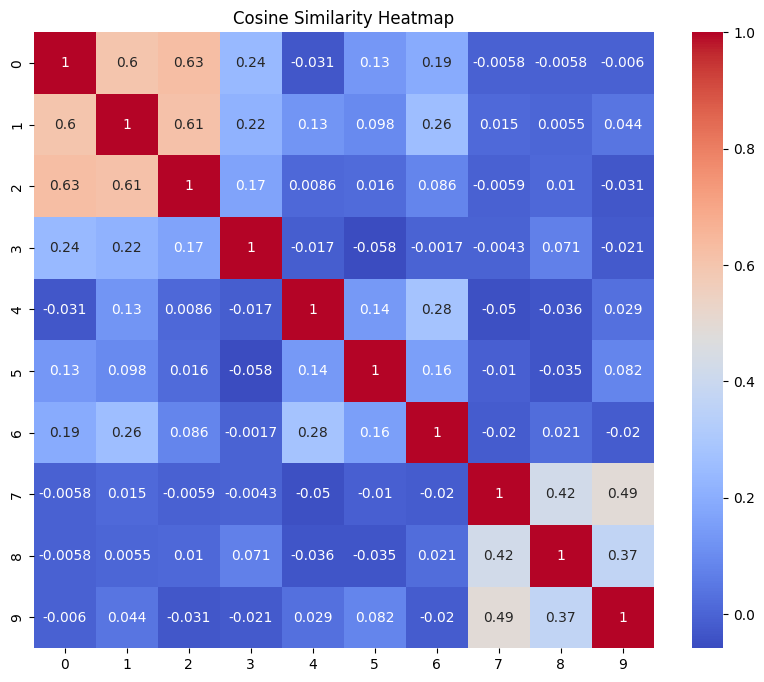

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')

plt.title("Cosine Similarity Heatmap")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_2_idx = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:")

for idx in top_2_idx:
    print(f"- {sentences[idx]} (Score: {similarities[idx]:.2f})")

Query: The bowler took three wickets in one over

Top 2 similar sentences:
- The bowler took five wickets in the game. (Score: 0.83)
- The batsman scored a century in the match. (Score: 0.56)
